# Step 1. Imports

In [71]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Step 2 - Load Excel file

In [72]:
# Exact file path
file_path = Path(r"C:\Users\ivank\Coding\macro_regime_project\data\master\US Yields.xlsx")

# Load only the Data sheet
df = pd.read_excel(file_path, sheet_name="Data")

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
#Check structure and view missing data
df.tail()
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        329 non-null    datetime64[us]
 1   1 Mo        329 non-null    float64       
 2   3 Mo        329 non-null    float64       
 3   6 Mo        329 non-null    float64       
 4   1 Yr        329 non-null    float64       
 5   2 Yr        329 non-null    float64       
 6   3 Yr        329 non-null    float64       
 7   5 Yr        329 non-null    float64       
 8   7 Yr        329 non-null    float64       
 9   10 Yr       329 non-null    float64       
 10  20 Yr       329 non-null    float64       
 11  30 Yr       329 non-null    float64       
 12  5Yr TIPS    329 non-null    float64       
 13  7Yr TIPS    329 non-null    float64       
 14  10Yr TIPS   329 non-null    float64       
 15  20 Yr TIPS  329 non-null    float64       
 16  30 Yr TIPS  329 non-null    float64  

Date          0
1 Mo          0
3 Mo          0
6 Mo          0
1 Yr          0
2 Yr          0
3 Yr          0
5 Yr          0
7 Yr          0
10 Yr         0
20 Yr         0
30 Yr         0
5Yr TIPS      0
7Yr TIPS      0
10Yr TIPS     0
20 Yr TIPS    0
30 Yr TIPS    0
dtype: int64

# Step 3 - Create BEI Columns

In [73]:
df["BEI_5yr"] = df["5 Yr"] - df["5Yr TIPS"]
df["BEI_7yr"] = df["7 Yr"] - df["7Yr TIPS"]
df["BEI_10Yr"] = df["10 Yr"] - df["10Yr TIPS"]
df["BEI_20Yr"] = df["20 Yr"] - df["20 Yr TIPS"]
df["BEI_30Yr"] = df["30 Yr"] - df["30 Yr TIPS"]

# Quick check
print(df.columns.tolist())
print(df.tail(3))

df.head()

['Date', '1 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr', '5Yr TIPS', '7Yr TIPS', '10Yr TIPS', '20 Yr TIPS', '30 Yr TIPS', 'BEI_5yr', 'BEI_7yr', 'BEI_10Yr', 'BEI_20Yr', 'BEI_30Yr']
          Date  1 Mo  3 Mo  6 Mo  1 Yr  2 Yr  3 Yr  5 Yr  7 Yr  10 Yr  ...  \
326 2026-04-04  3.71  3.71  3.73  3.72  3.84  3.88  3.99  4.17   4.35  ...   
327 2026-04-11  3.67  3.69  3.72  3.70  3.81  3.80  3.94  4.12   4.31  ...   
328 2026-04-17  3.69  3.70  3.69  3.64  3.71  3.72  3.84  4.04   4.26  ...   

     5Yr TIPS  7Yr TIPS  10Yr TIPS  20 Yr TIPS  30 Yr TIPS  BEI_5yr  BEI_7yr  \
326      1.38      1.70       1.99        2.44        2.67     2.61     2.47   
327      1.36      1.67       1.95        2.42        2.67     2.58     2.45   
328      1.28      1.61       1.90        2.40        2.65     2.56     2.43   

     BEI_10Yr  BEI_20Yr  BEI_30Yr  
326      2.36      2.47      2.24  
327      2.36      2.47      2.24  
328      2.36      2.45      2.23  

,Date,1 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,...,5Yr TIPS,7Yr TIPS,10Yr TIPS,20 Yr TIPS,30 Yr TIPS,BEI_5yr,BEI_7yr,BEI_10Yr,BEI_20Yr,BEI_30Yr
0,2020-01-03,1.52,1.52,1.55,1.55,1.53,1.54,1.59,1.71,1.80,...,-0.10,-0.05,0.03,0.26,0.45,1.69,1.76,1.77,1.85,1.81
1,2020-01-10,1.52,1.54,1.55,1.53,1.56,1.59,1.63,1.74,1.83,...,-0.04,0.01,0.07,0.29,0.47,1.67,1.73,1.76,1.85,1.81
2,2020-01-17,1.54,1.56,1.57,1.56,1.58,1.56,1.63,1.74,1.84,...,-0.05,0.01,0.09,0.31,0.49,1.68,1.73,1.75,1.85,1.80
3,2020-01-24,1.54,1.54,1.55,1.55,1.49,1.48,1.51,1.61,1.70,...,-0.11,-0.06,0.02,0.22,0.38,1.62,1.67,1.68,1.78,1.76
4,2020-01-31,1.56,1.55,1.54,1.45,1.33,1.30,1.32,1.42,1.51,...,-0.28,-0.22,-0.14,0.09,0.26,1.60,1.64,1.65,1.74,1.73


# Step 4 - Create yield curve spread columns

In [74]:
# Key nominal yield curve spreads
df["10Y_2Y"] = df["10 Yr"] - df["2 Yr"]
df["10Y_3M"] = df["10 Yr"] - df["3 Mo"]
df["30Y_5Y"] = df["30 Yr"] - df["5 Yr"]

# Optional: BEI curve shape spreads
df["BEI_10Y_5Y"] = df["BEI_10Yr"] - df["BEI_5yr"]
df["BEI_30Y_10Y"] = df["BEI_30Yr"] - df["BEI_10Yr"]
df["BEI_30Y_5Y"] = df["BEI_30Yr"] - df["BEI_5yr"]

# Quick check
cols_to_show = [
    "Date",
    "10Y_2Y",
    "10Y_3M",
    "30Y_5Y",
    "BEI_5yr",
    "BEI_10Yr",
    "BEI_30Yr",
    "BEI_10Y_5Y",
    "BEI_30Y_10Y",
    "BEI_30Y_5Y",
]

print(df[cols_to_show].tail(5))

          Date  10Y_2Y  10Y_3M  30Y_5Y  BEI_5yr  BEI_10Yr  BEI_30Yr  \
324 2026-03-21    0.51    0.65    0.95     2.63      2.38      2.24   
325 2026-03-28    0.56    0.71    0.92     2.56      2.31      2.20   
326 2026-04-04    0.51    0.64    0.92     2.61      2.36      2.24   
327 2026-04-11    0.50    0.62    0.97     2.58      2.36      2.24   
328 2026-04-17    0.55    0.56    1.04     2.56      2.36      2.23   

     BEI_10Y_5Y  BEI_30Y_10Y  BEI_30Y_5Y  
324       -0.25        -0.14       -0.39  
325       -0.25        -0.11       -0.36  
326       -0.25        -0.12       -0.37  
327       -0.22        -0.12       -0.34  
328       -0.20        -0.13       -0.33  


# Step 5 - Plots
-yield curve plots

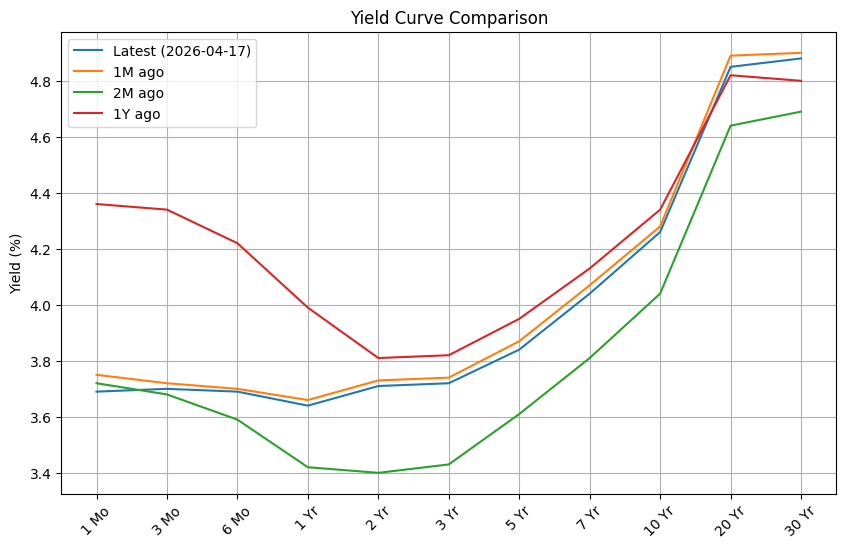

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure sorted
df = df.sort_values("Date").reset_index(drop=True)

# -----------------------------
# Helper: get closest date
# -----------------------------
def get_closest_date(target_date):
    return df.iloc[(df["Date"] - target_date).abs().argsort()[:1]]


latest_date = df["Date"].max()

date_1m = latest_date - pd.DateOffset(months=1)
date_2m = latest_date - pd.DateOffset(months=2)
date_1y = latest_date - pd.DateOffset(years=1)

latest = df[df["Date"] == latest_date]
curve_1m = get_closest_date(date_1m)
curve_2m = get_closest_date(date_2m)
curve_1y = get_closest_date(date_1y)

# -----------------------------
# Yield curve plot
# -----------------------------
maturities = [
    "1 Mo", "3 Mo", "6 Mo",
    "1 Yr", "2 Yr", "3 Yr",
    "5 Yr", "7 Yr", "10 Yr",
    "20 Yr", "30 Yr"
]

x = list(range(len(maturities)))

plt.figure(figsize=(10, 6))

plt.plot(x, latest[maturities].values.flatten(), label=f"Latest ({latest_date.date()})")
plt.plot(x, curve_1m[maturities].values.flatten(), label="1M ago")
plt.plot(x, curve_2m[maturities].values.flatten(), label="2M ago")
plt.plot(x, curve_1y[maturities].values.flatten(), label="1Y ago")

plt.xticks(x, maturities, rotation=45)
plt.title("Yield Curve Comparison")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid()

plt.show()

What you’re looking for:
- __Shape__
    - upward → normal (growth expectations)
    - flat → uncertainty
    - inverted → recession risk
What matters most:
- __Front end (1M–2Y)__ → Fed policy expectations
- __Long end (10Y–30Y)__ → growth + inflation expectations

Plot 2 — Key spreads over time

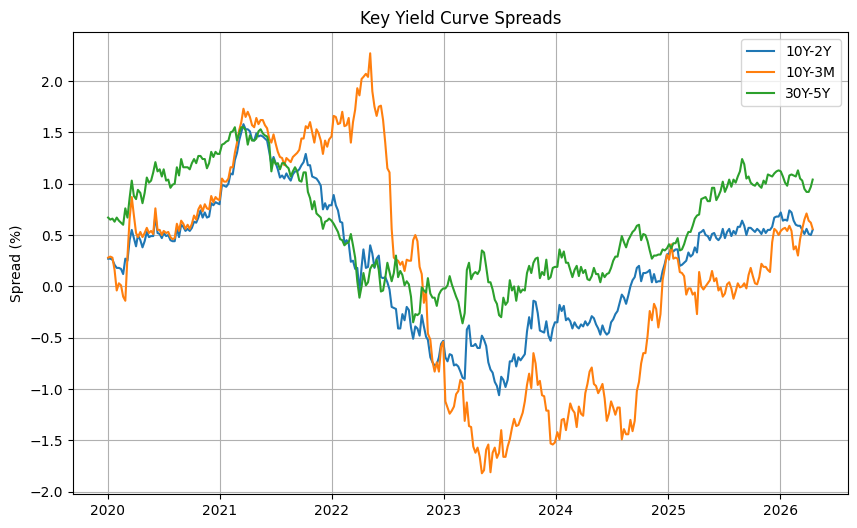

In [76]:
plt.figure(figsize=(10, 6))

plt.plot(df["Date"], df["10Y_2Y"], label="10Y-2Y")
plt.plot(df["Date"], df["10Y_3M"], label="10Y-3M")
plt.plot(df["Date"], df["30Y_5Y"], label="30Y-5Y")

plt.title("Key Yield Curve Spreads")
plt.ylabel("Spread (%)")
plt.legend()
plt.grid()

plt.show()

- __10Y–2Y__
    - most famous recession signal
    - negative → strong warning
- __10Y–3M__
    - even more policy-sensitive
    - deep negative → Fed too tight
- __30Y–5Y__
    - long-term structure
    - positive → normal long-term risk premium
- __What you’re watching:__
    - direction (rising vs falling)
    - level (deeply negative vs mildly negative)

Plot 3 - BEI levels

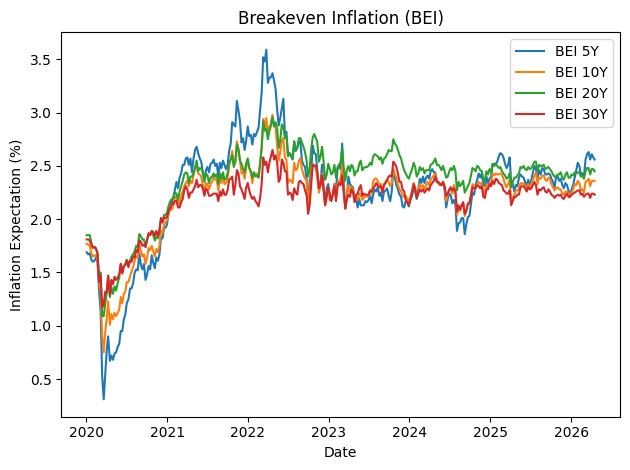

In [77]:
plt.figure()

plt.plot(df["Date"], df["BEI_5yr"], label="BEI 5Y")
plt.plot(df["Date"], df["BEI_10Yr"], label="BEI 10Y")
plt.plot(df["Date"], df["BEI_20Yr"], label="BEI 20Y")
plt.plot(df["Date"], df["BEI_30Yr"], label="BEI 30Y")

plt.title("Breakeven Inflation (BEI)")
plt.xlabel("Date")
plt.ylabel("Inflation Expectation (%)")
plt.legend()
plt.tight_layout()
plt.show()

- __This is market-implied inflation expectation.__
- __What you’re looking for:__
    - rising BEI → inflation expectations increasing
    - falling BEI → disinflation
- __interpretation:__
    - 5Yr < 10Yr < 30Yr --> long-term inflation concern
    - 5Yr > 10Yr --> near-term inflation shock
    - flattening --> stable expectations

# Step 6 - Quant Layer

In [78]:
# Make sure data is sorted and index is clean
df = df.sort_values("Date").reset_index(drop=True)

# ----------------------------
# 1. Define metrics to score
# ----------------------------
metrics_to_score = [
    "10Y_2Y",
    "10Y_3M",
    "30Y_5Y",
    "BEI_5yr",
    "BEI_10Yr",
    "BEI_20Yr",
    "BEI_30Yr",
    "BEI_10Y_5Y",
    "BEI_30Y_10Y",
    "BEI_30Y_5Y",
    "5Yr TIPS",
    "7Yr TIPS",
    "10Yr TIPS",
    "20 Yr TIPS",
    "30 Yr TIPS",
    "2 Yr",
    "10 Yr",
    "30 Yr",
]

# ----------------------------
# 2. Helper functions
# ----------------------------
def rolling_zscore(series, window=52):
    rolling_mean = series.rolling(window=window, min_periods=20).mean()
    rolling_std = series.rolling(window=window, min_periods=20).std()
    z = (series - rolling_mean) / rolling_std
    return z

def rolling_percentile(series, window=52):
    """
    Rolling percentile rank of the latest observation within the trailing window.
    Output between 0 and 1.
    """
    def pct_rank_last(x):
        s = pd.Series(x)
        return s.rank(pct=True).iloc[-1]

    return series.rolling(window=window, min_periods=20).apply(pct_rank_last, raw=False)

# ----------------------------
# 3. Build z-scores and rolling percentiles
# ----------------------------
for col in metrics_to_score:
    if col in df.columns:
        df[f"{col}_z52"] = rolling_zscore(df[col], window=52)
        df[f"{col}_pct52"] = rolling_percentile(df[col], window=52)

# ----------------------------
# 4. Build components for a proxy credit stress score
# ----------------------------
# Logic:
# - deeper inversion (more negative 10Y_2Y / 10Y_3M) => more stress
# - higher real yields => tighter financial conditions => more stress
# - lower BEI_10Yr => weaker inflation/growth expectations => more stress
#
# We orient each component so HIGHER = MORE STRESS

# Inversion stress: more negative slopes should mean more stress
df["invstress_10Y_2Y"] = -df["10Y_2Y"]
df["invstress_10Y_3M"] = -df["10Y_3M"]

# Real yield stress: higher real yields = tighter conditions
df["realstress_10Y"] = df["10Yr TIPS"]
df["realstress_30Y"] = df["30 Yr TIPS"]

# BEI compression stress: lower BEI = more stress / weaker pricing power
df["beistress_10Y"] = -df["BEI_10Yr"]

stress_components = [
    "invstress_10Y_2Y",
    "invstress_10Y_3M",
    "realstress_10Y",
    "realstress_30Y",
    "beistress_10Y",
]

# ----------------------------
# 5. Standardize stress components
# ----------------------------
for col in stress_components:
    df[f"{col}_z52"] = rolling_zscore(df[col], window=52)
    df[f"{col}_pct52"] = rolling_percentile(df[col], window=52)

# ----------------------------
# 6. Composite proxy credit stress score
# ----------------------------
# Equal-weight average of standardized stress components
z_cols = [f"{col}_z52" for col in stress_components]

df["credit_stress_score_raw"] = df[z_cols].mean(axis=1)

# Optional: normalize raw score into a 0-100 rolling percentile score
df["credit_stress_score_pct52"] = rolling_percentile(df["credit_stress_score_raw"], window=52) * 100

# ----------------------------
# 7. Regime labels for easier reading
# ----------------------------
def label_stress_score(x):
    if pd.isna(x):
        return np.nan
    elif x >= 80:
        return "High Stress"
    elif x >= 60:
        return "Elevated"
    elif x >= 40:
        return "Neutral"
    elif x >= 20:
        return "Low"
    else:
        return "Very Low"

df["credit_stress_regime"] = df["credit_stress_score_pct52"].apply(label_stress_score)

# ----------------------------
# 8. Quick check
# ----------------------------
check_cols = [
    "Date",
    "10Y_2Y",
    "10Y_2Y_z52",
    "10Y_2Y_pct52",
    "10Y_3M",
    "10Y_3M_z52",
    "10Y_3M_pct52",
    "BEI_10Yr",
    "BEI_10Yr_z52",
    "BEI_10Yr_pct52",
    "10Yr TIPS",
    "10Yr TIPS_z52",
    "10Yr TIPS_pct52",
    "credit_stress_score_raw",
    "credit_stress_score_pct52",
    "credit_stress_regime",
]

#print(df[check_cols].tail(10))

__z52 example:__
- tells how far the current value is from it's 52-week average, in standard deviations
    - +2.0: very high relative to the past year
    - 0.0: normal
    - 2.0: very low relative to past year

__pct52 exmple:__
- gives the rolling percentile over the past 52 weeks
    - 0.9: higher than 90% of the last 52 weeks
    - 0.5: median
    - 0.1: very low

__How to think about the proxy credit stress score.__
This score rises when:
- the curve is more inverted
- real yields are high
- breakeven inflation weakens

__So it is really a:__
- macro / financial tightness / stress proxy
- and not a true credit spread score.

In [79]:
# Step 7 - Automated answers to questions

In [80]:
# ----------------------------
# 1. Select latest observation
# ----------------------------
latest = df.dropna().iloc[-1]

date_str = latest["Date"].strftime("%Y-%m-%d")

# ----------------------------
# 2. Helper formatting
# ----------------------------
def fmt(x):
    try:
        return f"{x:.2f}"
    except:
        return "NA"

def pct(x):
    try:
        return f"{x*100:.0f}%"
    except:
        return "NA"

# ----------------------------
# 3. Build answers
# ----------------------------

answers = {}
def describe_slope(x, name):
    if pd.isna(x):
        return f"{name}: unavailable"
    if x < -0.5:
        return f"{name}: deeply inverted ({x:.2f})"
    elif x < 0:
        return f"{name}: inverted ({x:.2f})"
    elif x < 0.5:
        return f"{name}: mildly positive ({x:.2f})"
    else:
        return f"{name}: clearly positive ({x:.2f})"

def interpret_front_end(slope_10y2y, slope_10y3m):
    if pd.isna(slope_10y2y) or pd.isna(slope_10y3m):
        return "Front-end curve interpretation unavailable."
    if slope_10y2y < 0 and slope_10y3m < 0:
        return "Both front-end spreads are inverted, which points to a restrictive policy backdrop and weaker growth expectations."
    elif slope_10y2y >= 0 and slope_10y3m >= 0:
        return "Both front-end spreads are positive, which argues against an active inversion signal and suggests a more normal curve structure."
    else:
        return "The front-end curve is mixed, with one spread positive and one inverted, suggesting an incomplete normalization."
        
def interpret_real_yields(z):
    if pd.isna(z):
        return "Real yield context unavailable."
    if z > 1.0:
        return "Real yields are elevated relative to the past year, indicating tighter financial conditions."
    elif z < -1.0:
        return "Real yields are low relative to the past year, indicating easier financial conditions."
    else:
        return "Real yields are broadly neutral relative to the past year, suggesting stable financial conditions."

def interpret_bei_curve(spread_10y_5y, spread_30y_10y):
    if pd.isna(spread_10y_5y) or pd.isna(spread_30y_10y):
        return "BEI curve interpretation unavailable."

    if spread_10y_5y > 0 and spread_30y_10y > 0:
        return "The BEI curve is upward sloping, suggesting higher long-term inflation expectations relative to the front end."

    elif spread_10y_5y < 0 and spread_30y_10y < 0:
        return "The BEI curve is inverted, suggesting longer-term inflation expectations are below near-term expectations."

    else:
        return "The BEI curve is mixed, indicating an uneven inflation term structure."

def describe_change(current, past, label):
    if pd.isna(current) or pd.isna(past):
        return f"{label}: unavailable"

    delta = current - past

    if delta > 0.1:
        return f"{label}: steepened significantly (+{delta:.2f})"
    elif delta > 0:
        return f"{label}: steepened slightly (+{delta:.2f})"
    elif delta < -0.1:
        return f"{label}: flattened significantly ({delta:.2f})"
    elif delta < 0:
        return f"{label}: flattened slightly ({delta:.2f})"
    else:
        return f"{label}: unchanged ({delta:.2f})"

def classify_bei_level(z):
    if pd.isna(z):
        return "unavailable"
    if z > 1.5:
        return "very elevated"
    elif z > 0.5:
        return "moderately elevated"
    elif z > -0.5:
        return "neutral"
    elif z > -1.5:
        return "moderately low"
    else:
        return "very low"

def describe_simple_change(delta):
    if pd.isna(delta):
        return "unavailable"
    if delta > 0.1:
        return f"increased meaningfully (+{delta:.2f})"
    elif delta > 0:
        return f"increased slightly (+{delta:.2f})"
    elif delta < -0.1:
        return f"decreased meaningfully ({delta:.2f})"
    elif delta < 0:
        return f"decreased slightly ({delta:.2f})"
    else:
        return f"was unchanged ({delta:.2f})"
        
# Q1 — Curve shape
answers["Q1_curve_shape"] = f"""
Nominal curve:
- {describe_slope(latest['10Y_2Y'], '10Y–2Y')}
- {describe_slope(latest['10Y_3M'], '10Y–3M')}
- {describe_slope(latest['30Y_5Y'], '30Y–5Y')}

Interpretation:
- {interpret_front_end(latest['10Y_2Y'], latest['10Y_3M'])}
- The long-end slope reflects term premium and long-term growth/inflation expectations.
"""

# Q2 — Slope signals
answers["Q2_slopes"] = f"""
Slope signals:
- 10Y–2Y: {fmt(latest['10Y_2Y'])} (pct52: {pct(latest['10Y_2Y_pct52'])})
- 10Y–3M: {fmt(latest['10Y_3M'])} (pct52: {pct(latest['10Y_3M_pct52'])})
- 30Y–5Y: {fmt(latest['30Y_5Y'])}

Interpretation:
- 10Y–2Y is {describe_slope(latest['10Y_2Y'], 'Current').replace('Current: ', '')}.
- 10Y–3M is {describe_slope(latest['10Y_3M'], 'Current').replace('Current: ', '')}.
- The percentile values show where each spread sits versus the past 52 weeks, not whether it is inverted.
"""

# Q3 — Trend vs past
prev_1m = df.iloc[-5] if len(df) > 5 else latest
prev_3m = df.iloc[-13] if len(df) > 13 else latest
bei_1m_change = latest["BEI_10Yr"] - prev_1m["BEI_10Yr"]

answers["Q3_trend"] = f"""
Trend (10Y–2Y):
- Current: {fmt(latest['10Y_2Y'])}
- 1M ago: {fmt(prev_1m['10Y_2Y'])}
- 3M ago: {fmt(prev_3m['10Y_2Y'])}

Interpretation:
- {describe_change(latest['10Y_2Y'], prev_1m['10Y_2Y'], '1M change')}
- {describe_change(latest['10Y_2Y'], prev_3m['10Y_2Y'], '3M change')}
"""

# Q4 — Curve driver
answers["Q4_driver"] = f"""
Driver decomposition:
- 2Y: {fmt(latest['2 Yr'])}
- 10Y: {fmt(latest['10 Yr'])}
- 30Y: {fmt(latest['30 Yr'])}

Interpretation:
- Front-end reflects Fed policy expectations
- Long-end reflects growth + inflation + term premium
"""

# Q5 — Real yields
answers["Q5_real"] = f"""
Real yields:
- 5Y: {fmt(latest['5Yr TIPS'])}
- 10Y: {fmt(latest['10Yr TIPS'])}
- 30Y: {fmt(latest['30 Yr TIPS'])}

Interpretation:
- {interpret_real_yields(latest['10Yr TIPS_z52'])}
"""

# Q6 — Real yield context
answers["Q6_real_trend"] = f"""
Real yield context:
- 10Y TIPS z-score: {fmt(latest['10Yr TIPS_z52'])}
- 10Y TIPS percentile: {pct(latest['10Yr TIPS_pct52'])}

Interpretation:
- {interpret_real_yields(latest['10Yr TIPS_z52'])}
- The percentile shows the position within the past 52-week range.
"""

# Q7 — BEI levels
answers["Q7_bei_levels"] = f"""
Breakeven inflation:
- 5Y: {fmt(latest['BEI_5yr'])}
- 10Y: {fmt(latest['BEI_10Yr'])}
- 30Y: {fmt(latest['BEI_30Yr'])}

Interpretation:
- Market-implied inflation expectations
"""

# Q8 — BEI curve
answers["Q8_bei_curve"] = f"""
BEI curve shape:
- 10Y–5Y: {fmt(latest['BEI_10Y_5Y'])}
- 30Y–10Y: {fmt(latest['BEI_30Y_10Y'])}

Interpretation:
- {interpret_bei_curve(latest['BEI_10Y_5Y'], latest['BEI_30Y_10Y'])}
"""

# Q9 — BEI quant context
answers["Q9_bei_quant"] = f"""
BEI quant:
- 10Y BEI z-score: {fmt(latest['BEI_10Yr_z52'])}
- 10Y BEI percentile: {pct(latest['BEI_10Yr_pct52'])}

Interpretation:
- BEI 10Y is {classify_bei_level(latest['BEI_10Yr_z52'])}, based on its position relative to the past 52 weeks.
- It has {describe_simple_change(bei_1m_change)} over the past month.
"""

# Q10 — Regime synthesis
answers["Q10_regime"] = f"""
Regime signals:
- Growth proxy (10Y–2Y): {fmt(latest['10Y_2Y'])}
- Inflation proxy (BEI 10Y): {fmt(latest['BEI_10Yr'])}
- Liquidity proxy (real yields): {fmt(latest['10Yr TIPS'])}
- Stress score: {fmt(latest['credit_stress_score_pct52'])} ({latest['credit_stress_regime']})

Interpretation:
- Combine curve, BEI, and real yields to assess macro regime
"""

# ----------------------------
# 4. Print answers
# ----------------------------
for k, v in answers.items():
    print(f"\n{k}\n{'-'*40}")
    print(v)


Q1_curve_shape
----------------------------------------

Nominal curve:
- 10Y–2Y: clearly positive (0.55)
- 10Y–3M: clearly positive (0.56)
- 30Y–5Y: clearly positive (1.04)

Interpretation:
- Both front-end spreads are positive, which argues against an active inversion signal and suggests a more normal curve structure.
- The long-end slope reflects term premium and long-term growth/inflation expectations.


Q2_slopes
----------------------------------------

Slope signals:
- 10Y–2Y: 0.55 (pct52: 47%)
- 10Y–3M: 0.56 (pct52: 84%)
- 30Y–5Y: 1.04

Interpretation:
- 10Y–2Y is clearly positive (0.55).
- 10Y–3M is clearly positive (0.56).
- The percentile values show where each spread sits versus the past 52 weeks, not whether it is inverted.


Q3_trend
----------------------------------------

Trend (10Y–2Y):
- Current: 0.55
- 1M ago: 0.51
- 3M ago: 0.64

Interpretation:
- 1M change: steepened slightly (+0.04)
- 3M change: flattened slightly (-0.09)


Q4_driver
----------------------------

# Step 8 - Claude output

In [81]:
from pathlib import Path

# ----------------------------
# 1. Build final text block
# ----------------------------
latest = df.dropna().iloc[-1]
date_str = latest["Date"].strftime("%Y-%m-%d")

claude_output = f"""YIELD CURVE KPI OUTPUT
Date: {date_str}

1. CURRENT SNAPSHOT
- 10Y–2Y: {fmt(latest['10Y_2Y'])}
- 10Y–3M: {fmt(latest['10Y_3M'])}
- 30Y–5Y: {fmt(latest['30Y_5Y'])}
- 5Y real yield: {fmt(latest['5Yr TIPS'])}
- 10Y real yield: {fmt(latest['10Yr TIPS'])}
- 30Y real yield: {fmt(latest['30 Yr TIPS'])}
- BEI 5Y: {fmt(latest['BEI_5yr'])}
- BEI 7Y: {fmt(latest['BEI_7yr'])}
- BEI 10Y: {fmt(latest['BEI_10Yr'])}
- BEI 20Y: {fmt(latest['BEI_20Yr'])}
- BEI 30Y: {fmt(latest['BEI_30Yr'])}

2. QUANT CONTEXT
- 10Y–2Y z-score (52w): {fmt(latest['10Y_2Y_z52'])}
- 10Y–2Y percentile (52w): {pct(latest['10Y_2Y_pct52'])}
- 10Y–3M z-score (52w): {fmt(latest['10Y_3M_z52'])}
- 10Y–3M percentile (52w): {pct(latest['10Y_3M_pct52'])}
- 10Y real yield z-score (52w): {fmt(latest['10Yr TIPS_z52'])}
- 10Y real yield percentile (52w): {pct(latest['10Yr TIPS_pct52'])}
- BEI 10Y z-score (52w): {fmt(latest['BEI_10Yr_z52'])}
- BEI 10Y percentile (52w): {pct(latest['BEI_10Yr_pct52'])}
- Credit stress score percentile (52w): {fmt(latest['credit_stress_score_pct52'])}
- Credit stress regime: {latest['credit_stress_regime']}

3. AUTOMATED ANSWERS

Q1. What is the current shape of the nominal yield curve?
{answers['Q1_curve_shape'].strip()}

Q2. What do the key slope spreads say?
{answers['Q2_slopes'].strip()}

Q3. Is the curve steepening or flattening?
{answers['Q3_trend'].strip()}

Q4. Which part of the curve is driving the move?
{answers['Q4_driver'].strip()}

Q5. What do real yields say?
{answers['Q5_real'].strip()}

Q6. How extreme are real yields versus history?
{answers['Q6_real_trend'].strip()}

Q7. What are current breakeven inflation levels?
{answers['Q7_bei_levels'].strip()}

Q8. What does the BEI curve shape say?
{answers['Q8_bei_curve'].strip()}

Q9. How extreme are breakeven inflation levels versus history?
{answers['Q9_bei_quant'].strip()}

Q10. What is the combined regime message?
{answers['Q10_regime'].strip()}

4. REGIME SUMMARY
Growth:
- Use 10Y–2Y and 10Y–3M as primary growth-cycle signals.

Inflation:
- Use BEI levels and BEI curve shape as inflation-expectation signals.

Liquidity / Financial Conditions:
- Use real yields, especially 10Y TIPS, as primary tightness signals.

Volatility:
- Use fast changes in slopes and BEI structure as warning signs of macro repricing.

Credit:
- Use the proxy credit stress score as a temporary internal stress gauge.

5. PLAIN-ENGLISH CONCLUSION
- Summarize whether the curve is inverted or steepening.
- Summarize whether real yields are tight or easing.
- Summarize whether inflation expectations are rising, falling, or stable.
- Summarize whether the overall regime is risk-on, restrictive, reflationary, or growth-negative.
"""

# ----------------------------
# 2. Save to file
# ----------------------------
output_dir = Path(r"C:\Users\ivank\Coding\macro_regime_project\outputs\claude")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "yield_curve_kpi_output.txt"

with open(output_file, "w", encoding="utf-8") as f:
    f.write(claude_output)

print(f"Saved Claude output file to:\n{output_file}")

Saved Claude output file to:
C:\Users\ivank\Coding\macro_regime_project\outputs\claude\yield_curve_kpi_output.txt


In [82]:
def classify_curve_signal(x):
    if pd.isna(x):
        return "unknown"
    if x < -0.5:
        return "deeply inverted"
    elif x < 0:
        return "inverted"
    elif x < 0.5:
        return "flat to mildly positive"
    else:
        return "positively sloped"

def classify_real_yield(z):
    if pd.isna(z):
        return "unknown"
    if z > 1.0:
        return "tight"
    elif z < -1.0:
        return "easy"
    else:
        return "neutral"

def classify_bei(z):
    if pd.isna(z):
        return "unknown"
    if z > 1.0:
        return "elevated"
    elif z < -1.0:
        return "depressed"
    else:
        return "neutral"

def classify_stress(pct_score):
    if pd.isna(pct_score):
        return "unknown"
    if pct_score >= 80:
        return "high stress"
    elif pct_score >= 60:
        return "elevated stress"
    elif pct_score >= 40:
        return "neutral stress"
    else:
        return "low stress"

latest = df.dropna().iloc[-1]

curve_10y2y = classify_curve_signal(latest["10Y_2Y"])
curve_10y3m = classify_curve_signal(latest["10Y_3M"])
real_regime = classify_real_yield(latest["10Yr TIPS_z52"])
bei_regime = classify_bei(latest["BEI_10Yr_z52"])
stress_regime = classify_stress(latest["credit_stress_score_pct52"])

curve_state = describe_slope(latest["10Y_2Y"], "").replace(": ", "")
real_state = interpret_real_yields(latest["10Yr TIPS_z52"])
bei_state = classify_bei_level(latest["BEI_10Yr_z52"])
bei_trend = describe_simple_change(bei_1m_change)
stress_state = classify_stress(latest["credit_stress_score_pct52"])

plain_english_conclusion = f"""
The nominal curve is {curve_state}, which argues against a classic inversion-driven recession signal.

{real_state}

Inflation expectations are {bei_state} and have {bei_trend} over the past month, suggesting a stable to evolving inflation outlook.

The internal macro stress proxy currently indicates {stress_state}.

Overall, the combination of a positively sloped curve, neutral real yields, and moderately elevated but stabilizing inflation expectations suggests a mixed macro environment. 

While the absence of inversion argues against an immediate recession signal, the elevated stress proxy indicates that financial conditions are not fully benign. The current regime is therefore best characterized as stable but cautious, rather than strongly risk-on or risk-off.
"""

print(plain_english_conclusion)


The nominal curve is clearly positive (0.55), which argues against a classic inversion-driven recession signal.

Real yields are broadly neutral relative to the past year, suggesting stable financial conditions.

Inflation expectations are moderately elevated and have decreased slightly (-0.02) over the past month, suggesting a stable to evolving inflation outlook.

The internal macro stress proxy currently indicates elevated stress.

Overall, the combination of a positively sloped curve, neutral real yields, and moderately elevated but stable inflation expectations points to a broadly stable macro environment rather than a strongly risk-off or recessionary regime.



In [83]:
from pathlib import Path

latest = df.dropna().iloc[-1]
date_str = latest["Date"].strftime("%Y-%m-%d")

claude_output = f"""YIELD CURVE KPI OUTPUT
Date: {date_str}

1. CURRENT SNAPSHOT
- 10Y–2Y: {fmt(latest['10Y_2Y'])}
- 10Y–3M: {fmt(latest['10Y_3M'])}
- 30Y–5Y: {fmt(latest['30Y_5Y'])}
- 5Y real yield: {fmt(latest['5Yr TIPS'])}
- 10Y real yield: {fmt(latest['10Yr TIPS'])}
- 30Y real yield: {fmt(latest['30 Yr TIPS'])}
- BEI 5Y: {fmt(latest['BEI_5yr'])}
- BEI 7Y: {fmt(latest['BEI_7yr'])}
- BEI 10Y: {fmt(latest['BEI_10Yr'])}
- BEI 20Y: {fmt(latest['BEI_20Yr'])}
- BEI 30Y: {fmt(latest['BEI_30Yr'])}

2. QUANT CONTEXT
- 10Y–2Y z-score (52w): {fmt(latest['10Y_2Y_z52'])}
- 10Y–2Y percentile (52w): {pct(latest['10Y_2Y_pct52'])}
- 10Y–3M z-score (52w): {fmt(latest['10Y_3M_z52'])}
- 10Y–3M percentile (52w): {pct(latest['10Y_3M_pct52'])}
- 10Y real yield z-score (52w): {fmt(latest['10Yr TIPS_z52'])}
- 10Y real yield percentile (52w): {pct(latest['10Yr TIPS_pct52'])}
- BEI 10Y z-score (52w): {fmt(latest['BEI_10Yr_z52'])}
- BEI 10Y percentile (52w): {pct(latest['BEI_10Yr_pct52'])}
- Credit stress score percentile (52w): {fmt(latest['credit_stress_score_pct52'])}
- Credit stress regime: {latest['credit_stress_regime']}

3. AUTOMATED ANSWERS

Q1. What is the current shape of the nominal yield curve?
{answers['Q1_curve_shape'].strip()}

Q2. What do the key slope spreads say?
{answers['Q2_slopes'].strip()}

Q3. Is the curve steepening or flattening?
{answers['Q3_trend'].strip()}

Q4. Which part of the curve is driving the move?
{answers['Q4_driver'].strip()}

Q5. What do real yields say?
{answers['Q5_real'].strip()}

Q6. How extreme are real yields versus history?
{answers['Q6_real_trend'].strip()}

Q7. What are current breakeven inflation levels?
{answers['Q7_bei_levels'].strip()}

Q8. What does the BEI curve shape say?
{answers['Q8_bei_curve'].strip()}

Q9. How extreme are breakeven inflation levels versus history?
{answers['Q9_bei_quant'].strip()}

Q10. What is the combined regime message?
{answers['Q10_regime'].strip()}

4. REGIME SUMMARY
Growth:
- Use 10Y–2Y and 10Y–3M as primary growth-cycle signals.

Inflation:
- Use BEI levels and BEI curve shape as inflation-expectation signals.

Liquidity / Financial Conditions:
- Use real yields, especially 10Y TIPS, as primary tightness signals.

Volatility:
- Use fast changes in slopes and BEI structure as warning signs of macro repricing.

Credit:
- Use the proxy credit stress score as a temporary internal stress gauge.

5. PLAIN-ENGLISH CONCLUSION
{plain_english_conclusion.strip()}
"""

output_dir = Path(r"C:\Users\ivank\Coding\macro_regime_project\outputs\claude")
output_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Build date-based filename
# ----------------------------
file_date = latest["Date"].strftime("%Y-%m-%d")

output_file = output_dir / f"yield_curve_kpi_{file_date}.txt"

# ----------------------------
# Save file (overwrite only if same date)
# ----------------------------
with open(output_file, "w", encoding="utf-8") as f:
    f.write(claude_output)

print(f"Saved Claude output file to:\n{output_file}")

Saved Claude output file to:
C:\Users\ivank\Coding\macro_regime_project\outputs\claude\yield_curve_kpi_2026-04-17.txt
